# Avance de Proyecto

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargamos los datos
df = pd.read_csv('train.csv') 

1. Análisis Descriptivo

In [ ]:
print("--- Estadística descriptiva ---")
display(df.describe())

# Identificamos los tipos de variablesv
print("\n--- Tipos de datos ---")
print(df.dtypes)

# Revisamos los valores faltantes
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())

--- Estadística descriptiva ---


,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000



--- Tipos de datos ---
id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                    

### ¿Qué queremos descubrir?

Buscamos responder tres preguntas clave que nos permitan comprender y gestionar nuestros datos de manera efectiva. Al plantearlas cuidadosamente, facilitamos su análisis y obtenemos una visión más clara. Gracias a estas preguntas, podemos definir qué datos utilizaremos y cómo los administraremos.

1. Relación entre el tamaño físico (bedrooms, bathrooms, beds) y el precio.
2. El impacto del vecindario (neighbourhood) frente a las características del inmueble.
3. Diferencia de precios según el tipo de propiedad y de habitación.

2. Limpieza de datos e imputación de datos

In [ ]:
# Rellenamos los valores nulos en las variables numéricas con la mediana
columnasClave = ["bedrooms", "bathrooms", "beds"]

for col in columnasClave:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# En el vencindario los que falten los marcaremos como "Sin Categoría" y no perdemos datos
df["neighbourhood"] = df["neighbourhood"].fillna("Unknow")

# Validamos que no existan nulos en nuestras variables de interés
print("\n--- Validación de limpienza")
print(df[columnasClave + ['neighbourhood']].isnull().sum())


--- Validación de limpienza
bedrooms         0
bathrooms        0
beds             0
neighbourhood    0
dtype: int64


3. Análisis Descriptivo Profundo

In [ ]:
print("- - - Análisis de variables que influyen en el precio - - -")
print(df[["log_price", "bedrooms", "bathrooms", "accommodates"]].describe())

print("\n- - - Precio promedio por tipo de habitación - - -")
print(df.groupby('room_type')['log_price'].mean().sort_values(ascending=False))

- - - Análisis de variables que influyen en el precio - - -
          log_price      bedrooms     bathrooms  accommodates
count  74111.000000  74111.000000  74111.000000  74111.000000
mean       4.782069      1.265467      1.234628      3.155146
std        0.717394      0.851671      0.581386      2.153589
min        0.000000      0.000000      0.000000      1.000000
25%        4.317488      1.000000      1.000000      2.000000
50%        4.709530      1.000000      1.000000      2.000000
75%        5.220356      1.000000      1.000000      4.000000
max        7.600402     10.000000      8.000000     16.000000

- - - Precio promedio por tipo de habitación - - -
room_type
Entire home/apt    5.167217
Private room       4.327753
Shared room        3.861535
Name: log_price, dtype: float64


/tmp/ipykernel_20708/1182271374.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='log_price', palette='viridis')


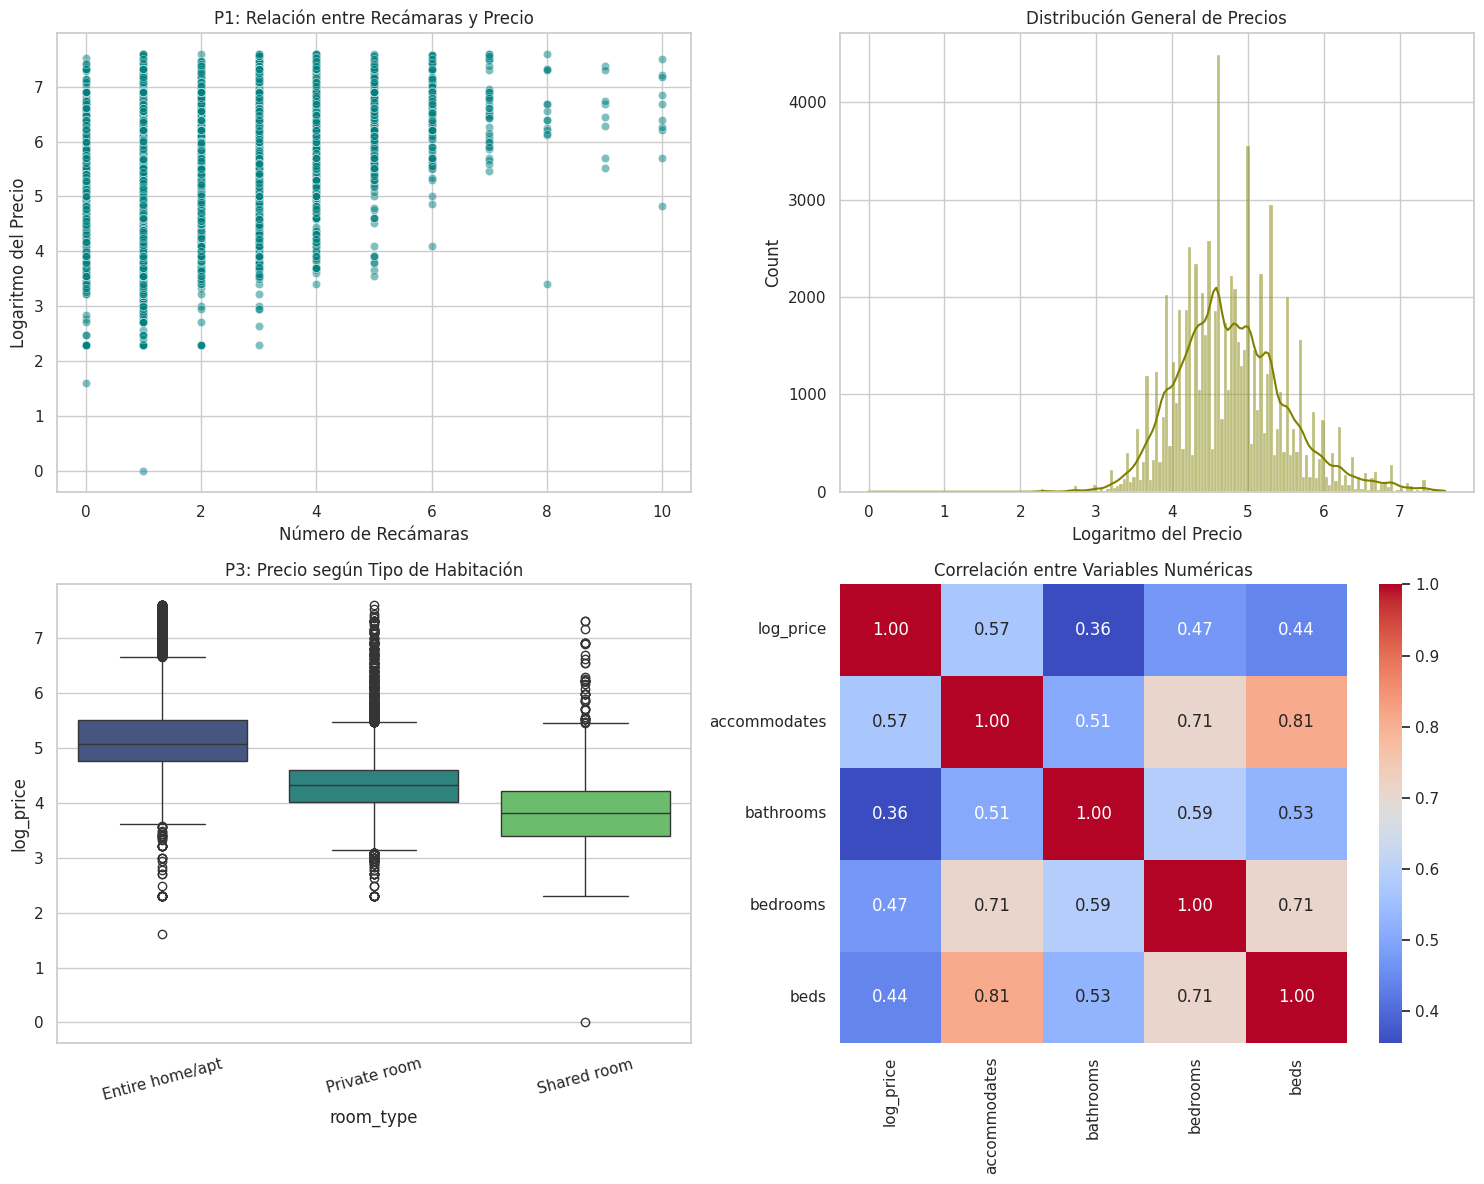

In [ ]:
# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# Gráfica 1: Relación entre Recámaras y Precio
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='bedrooms', y='log_price', alpha=0.5, color='teal')
plt.title('P1: Relación entre Recámaras y Precio')
plt.xlabel('Número de Recámaras')
plt.ylabel('Logaritmo del Precio')

# Gráfica 2: Distribución del Precio (Histograma)
plt.subplot(2, 2, 2)
sns.histplot(df['log_price'], kde=True, color='olive')
plt.title('Distribución General de Precios')
plt.xlabel('Logaritmo del Precio')

# Gráfica 3: Precio por Tipo de Habitación
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='room_type', y='log_price', palette='viridis')
plt.title('P3: Precio según Tipo de Habitación')
plt.xticks(rotation=15)

# Gráfica 4: Mapa de Calor de Correlación 
plt.subplot(2, 2, 4)
columnas_num = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds']
sns.heatmap(df[columnas_num].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas')

plt.tight_layout()
plt.show()

/tmp/ipykernel_20708/3162643742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_barrios, x='neighbourhood', y='log_price', palette='magma', errorbar=None)


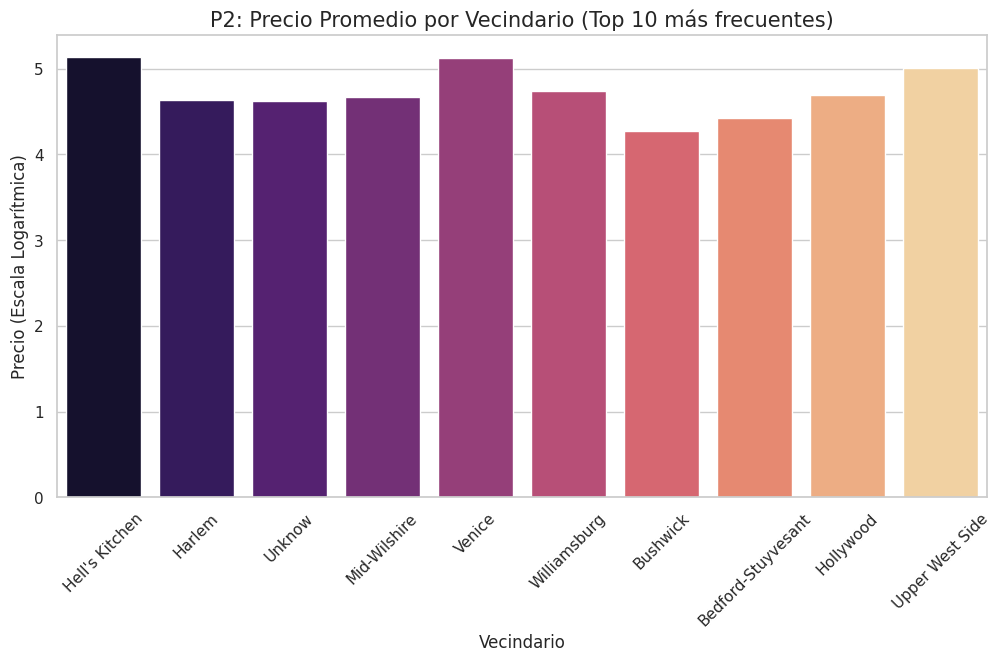

In [ ]:
# 1. Identificamos los 10 vecindarios con más anuncios para que el análisis sea sólido
top_10_vecindarios = df['neighbourhood'].value_counts().head(10).index

# 2. Filtramos el dataset solo con esos 10 barrios
df_barrios = df[df['neighbourhood'].isin(top_10_vecindarios)]

# 3. Graficamos
plt.figure(figsize=(12, 6))
sns.barplot(data=df_barrios, x='neighbourhood', y='log_price', palette='magma', errorbar=None)

plt.title('P2: Precio Promedio por Vecindario (Top 10 más frecuentes)', fontsize=15)
plt.xlabel('Vecindario', fontsize=12)
plt.ylabel('Precio (Escala Logarítmica)', fontsize=12)
plt.xticks(rotation=45) 
plt.show()

## Conclusiones 

* Factor principal: Tras el análisis de correlación, logramos determinar que la cantidad de huéspedes es la variable que más llega a influir en el precio final asi mismo seguida por el número de habitaciones 

* Tipos de Propiedad: Existe una jerarquía clara donde las propiedades completas representan el segmento de mayor costo, diferenciándose drásticamente de las habitaciones compartidas.

* Ubicación: La gráfica No 5 no muestra que ciertos vecindarios (una muestra de 10) llegan a elevar bastante el precio promedio, ya sea por la seguridad, o que tan cerca esten de ubicaciones emblematicas, lo cual podemos tomar que la ubicación es un factor clave del por que se eleva el precio

* Limpieza de Datos: Se realizó una imputación de valores faltantes en variables clave (bedrooms, bathrooms) para asegurar que el análisis estadístico no estuviera sesgado por datos nulos.